# Ridge & Lasso Regression with NumPy

Both algorithms implemented from scratch on California Housing.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| **Penalty** | $\alpha \sum \beta_j^2$ | $\alpha \sum |\beta_j|$ |
| **Solution** | Closed-form analytic | Coordinate descent (iterative) |
| **Effect** | Shrinks all coefficients toward 0 | Can shrink coefficients to exactly 0 |
| **Use case** | Multicollinearity | Feature selection |

Models saved to `../Models/ridge_numpy.npz` and `../Models/lasso_numpy.npz`.

## 1. Load & Prepare Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

raw      = fetch_california_housing(as_frame=True)
features = list(raw.feature_names)
X_raw    = raw.frame[features].values.astype(np.float64)
y        = raw.frame['MedHouseVal'].values.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}  |  Features: {len(features)}")

Train: 16,512  |  Test: 4,128  |  Features: 8


## 2. Standardise Features

**Regularisation penalises large coefficients.** If features are on different scales,
a feature with a large scale will have a naturally small coefficient and escape the penalty
while a feature with a small scale gets unfairly penalised.
Always standardise before regularised regression.

In [2]:
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0, ddof=1)
y_mean = y_train.mean()

X_train_sc = (X_train - X_mean) / X_std
X_test_sc  = (X_test  - X_mean) / X_std

# Centre y — allows us to fit without an intercept term during regularisation,
# then add back the mean at prediction time.
y_train_c = y_train - y_mean
y_test_c  = y_test  - y_mean

## 3. Baseline — OLS (No Regularisation)

$$\beta_{OLS} = (X^T X)^{-1} X^T y$$

In [3]:
def regression_metrics(y_true, y_pred, label):
    resid = y_true - y_pred
    mse   = np.mean(resid ** 2)
    rmse  = np.sqrt(mse)
    r2    = 1 - np.sum(resid**2) / np.sum((y_true - y_true.mean())**2)
    print(f"{label:<22} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return dict(MSE=mse, RMSE=rmse, R2=r2)


beta_ols = np.linalg.lstsq(X_train_sc, y_train_c, rcond=None)[0]

y_pred_ols_test = X_test_sc @ beta_ols + y_mean
metrics_ols = regression_metrics(y_test, y_pred_ols_test, 'OLS (no reg)')

OLS (no reg)           | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


---
# Part A — Ridge Regression (L2)

**Loss function:**
$$J(\beta) = \frac{1}{n}\|y - X\beta\|^2 + \alpha \|\beta\|^2$$

**Closed-form solution** — adding $\alpha I$ to $X^TX$ makes it invertible even when features are collinear:
$$\beta_{Ridge} = (X^T X + \alpha I)^{-1} X^T y$$

- $\alpha = 0$ → plain OLS
- $\alpha \to \infty$ → all coefficients shrink to 0
- Ridge **never** sets a coefficient exactly to 0 (L2 ball is smooth, no corners)

In [4]:
def ridge(X, y, alpha):
    """
    Ridge closed-form: β = (XᵀX + αI)⁻¹ Xᵀy
    Intercept is NOT penalised — pass centred y and standardised X.
    """
    n, p  = X.shape
    I     = np.eye(p)
    return np.linalg.solve(X.T @ X + alpha * I, X.T @ y)

## Ridge — Alpha Sweep & Coefficient Paths

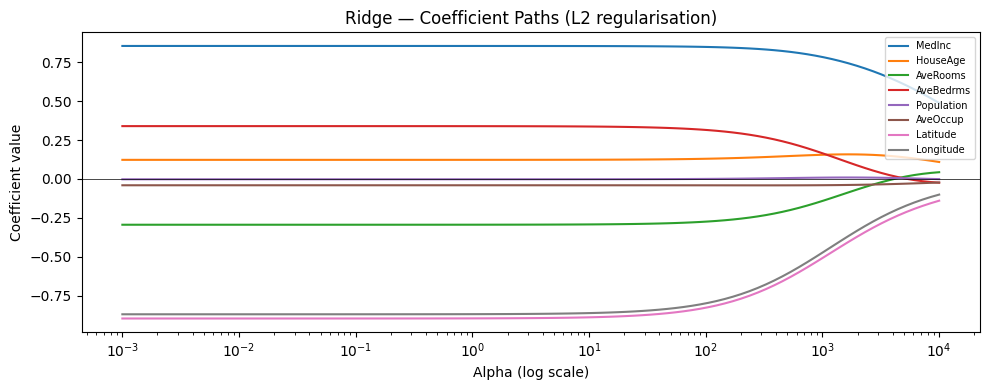

In [5]:
alphas = np.logspace(-3, 4, 100)
ridge_coefs = np.array([ridge(X_train_sc, y_train_c, a) for a in alphas])  # (100, p)

plt.figure(figsize=(10, 4))
for j, feat in enumerate(features):
    plt.semilogx(alphas, ridge_coefs[:, j], label=feat)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('Ridge — Coefficient Paths (L2 regularisation)')
plt.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

## Ridge — Cross-Validated Alpha Selection (Manual)

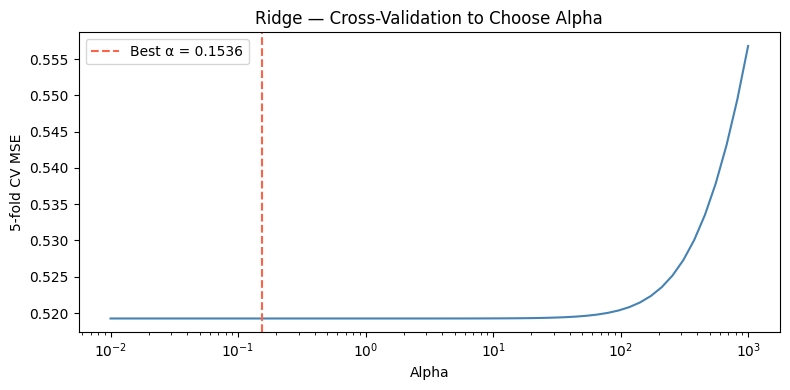

Best alpha (Ridge): 0.1536


In [6]:
def kfold_ridge_mse(X, y, alpha, k=5):
    n      = len(X)
    idx    = np.arange(n)
    folds  = np.array_split(idx, k)
    scores = []
    for i in range(k):
        val   = folds[i]
        train = np.concatenate([folds[j] for j in range(k) if j != i])
        b     = ridge(X[train], y[train], alpha)
        pred  = X[val] @ b
        scores.append(np.mean((y[val] - pred) ** 2))
    return np.mean(scores)

cv_alphas     = np.logspace(-2, 3, 60)
cv_mse_ridge  = [kfold_ridge_mse(X_train_sc, y_train_c, a) for a in cv_alphas]
best_alpha_ridge = cv_alphas[np.argmin(cv_mse_ridge)]

plt.figure(figsize=(8, 4))
plt.semilogx(cv_alphas, cv_mse_ridge, color='steelblue')
plt.axvline(best_alpha_ridge, linestyle='--', color='tomato',
            label=f'Best α = {best_alpha_ridge:.4f}')
plt.xlabel('Alpha'); plt.ylabel('5-fold CV MSE')
plt.title('Ridge — Cross-Validation to Choose Alpha')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Best alpha (Ridge): {best_alpha_ridge:.4f}")

## Ridge — Evaluate Best Model

In [7]:
beta_ridge = ridge(X_train_sc, y_train_c, best_alpha_ridge)

y_pred_ridge_train = X_train_sc @ beta_ridge + y_mean
y_pred_ridge_test  = X_test_sc  @ beta_ridge + y_mean

metrics_ols   = regression_metrics(y_test, y_pred_ols_test,          'OLS (no reg)')
metrics_ridge = regression_metrics(y_test, y_pred_ridge_test,        f'Ridge (α={best_alpha_ridge:.3f})')

OLS (no reg)           | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758
Ridge (α=0.154)        | MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


---
# Part B — Lasso Regression (L1)

**Loss function:**
$$J(\beta) = \frac{1}{2n}\|y - X\beta\|^2 + \alpha \|\beta\|_1$$

**No closed form** — the L1 penalty creates a non-differentiable kink at $\beta_j = 0$.
We solve it with **coordinate descent**: update one coefficient at a time, holding the rest fixed.

**Coordinate descent update for $\beta_j$:**

1. Compute partial residual (all predictions except feature $j$):
$$r_j = y - \sum_{k \neq j} X_k \beta_k$$

2. Compute the OLS solution for $\beta_j$ alone:
$$\rho_j = \frac{1}{n} X_j^T r_j$$

3. Apply **soft thresholding** (the effect of the L1 penalty):
$$\beta_j \leftarrow \mathcal{S}(\rho_j,\, \alpha) = \text{sign}(\rho_j)\cdot\max(|\rho_j| - \alpha,\ 0)$$

If $|\rho_j| \leq \alpha$, the coefficient is set to exactly **zero** — this is where Lasso's feature
selection comes from. The L1 ball has corners at the axes; the optimum lands on a corner.

In [8]:
def soft_threshold(rho, alpha):
    """Soft thresholding operator S(ρ, α) = sign(ρ) * max(|ρ| - α, 0)."""
    return np.sign(rho) * np.maximum(np.abs(rho) - alpha, 0)


def lasso(X, y, alpha, max_iter=1000, tol=1e-6):
    """
    Lasso via coordinate descent.
    Assumes X is standardised (so X_j^T X_j / n ≈ 1 for all j).

    Update rule per coefficient j:
        rho_j  = (1/n) * X_j^T * (y - X @ beta + X_j * beta_j)
        beta_j = soft_threshold(rho_j, alpha) / (X_j^T X_j / n)
    """
    n, p      = X.shape
    beta      = np.zeros(p)
    norm_sq   = (X ** 2).sum(axis=0) / n   # (p,)  X_j^T X_j / n
    losses    = []

    for iteration in range(max_iter):
        beta_prev = beta.copy()

        for j in range(p):
            # Partial residual: remove contribution of feature j
            r_j   = y - X @ beta + X[:, j] * beta[j]
            rho_j = (X[:, j] @ r_j) / n
            beta[j] = soft_threshold(rho_j, alpha) / norm_sq[j]

        loss = np.mean((y - X @ beta)**2) / 2 + alpha * np.sum(np.abs(beta))
        losses.append(loss)

        if np.max(np.abs(beta - beta_prev)) < tol:
            break

    return beta, losses, iteration + 1

## Lasso — Alpha Sweep & Coefficient Paths

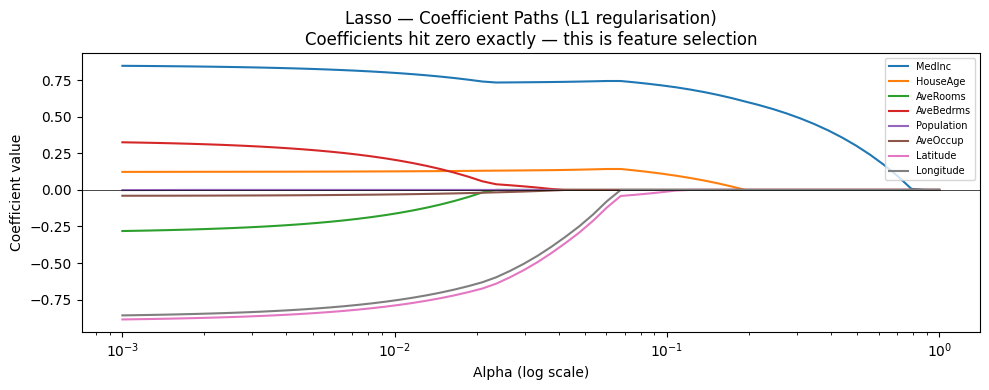

In [9]:
lasso_alphas = np.logspace(-3, 0, 60)
lasso_coefs  = []
for a in lasso_alphas:
    b, _, _ = lasso(X_train_sc, y_train_c, alpha=a)
    lasso_coefs.append(b)
lasso_coefs = np.array(lasso_coefs)   # (60, p)

plt.figure(figsize=(10, 4))
for j, feat in enumerate(features):
    plt.semilogx(lasso_alphas, lasso_coefs[:, j], label=feat)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso — Coefficient Paths (L1 regularisation)\nCoefficients hit zero exactly — this is feature selection')
plt.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

## Lasso — Cross-Validated Alpha Selection

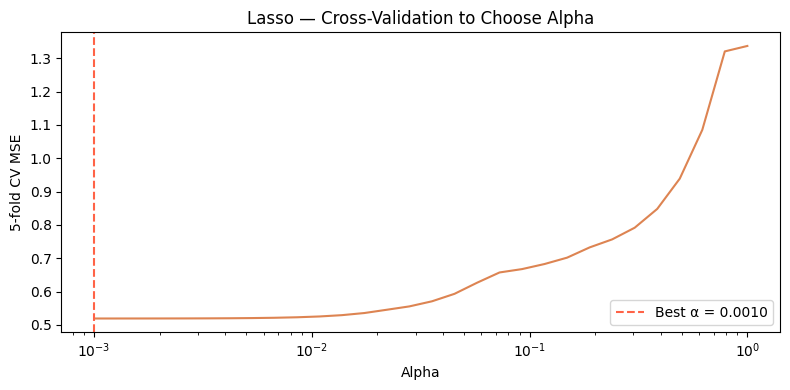

Best alpha (Lasso): 0.0010


In [10]:
def kfold_lasso_mse(X, y, alpha, k=5):
    n, idx = len(X), np.arange(len(X))
    folds  = np.array_split(idx, k)
    scores = []
    for i in range(k):
        val   = folds[i]
        train = np.concatenate([folds[j] for j in range(k) if j != i])
        b, _, _ = lasso(X[train], y[train], alpha)
        scores.append(np.mean((y[val] - X[val] @ b) ** 2))
    return np.mean(scores)

cv_alphas_l    = np.logspace(-3, 0, 30)
cv_mse_lasso   = [kfold_lasso_mse(X_train_sc, y_train_c, a) for a in cv_alphas_l]
best_alpha_lasso = cv_alphas_l[np.argmin(cv_mse_lasso)]

plt.figure(figsize=(8, 4))
plt.semilogx(cv_alphas_l, cv_mse_lasso, color='#DD8452')
plt.axvline(best_alpha_lasso, linestyle='--', color='tomato',
            label=f'Best α = {best_alpha_lasso:.4f}')
plt.xlabel('Alpha'); plt.ylabel('5-fold CV MSE')
plt.title('Lasso — Cross-Validation to Choose Alpha')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Best alpha (Lasso): {best_alpha_lasso:.4f}")

## Lasso — Convergence

Converged in 110 iterations


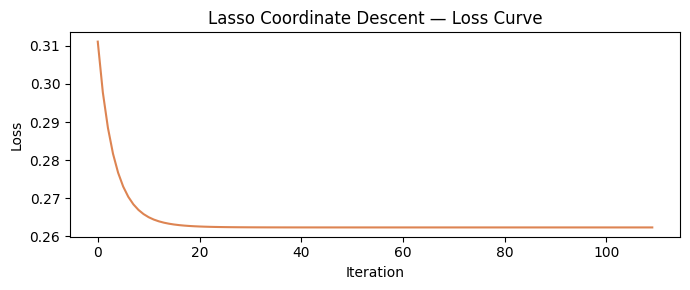

In [11]:
beta_lasso, lasso_losses, n_iter = lasso(X_train_sc, y_train_c, best_alpha_lasso)
print(f"Converged in {n_iter} iterations")

plt.figure(figsize=(7, 3))
plt.plot(lasso_losses, color='#DD8452')
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Lasso Coordinate Descent — Loss Curve')
plt.tight_layout(); plt.show()

## Lasso — Evaluate & Feature Selection

In [12]:
y_pred_lasso_test = X_test_sc @ beta_lasso + y_mean
metrics_lasso = regression_metrics(y_test, y_pred_lasso_test, f'Lasso (α={best_alpha_lasso:.4f})')

n_zero = np.sum(np.abs(beta_lasso) < 1e-8)
print(f"\nCoefficients set to zero: {n_zero} / {len(features)}")
print("Surviving features:",
      [f for f, b in zip(features, beta_lasso) if abs(b) >= 1e-8])

Lasso (α=0.0010)       | MSE: 0.5545 | RMSE: 0.7446 | R²: 0.5769

Coefficients set to zero: 0 / 8
Surviving features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## OLS vs Ridge vs Lasso — Full Comparison

          MSE    RMSE      R2
Model                        
OLS    0.5559  0.7456  0.5758
Ridge  0.5559  0.7456  0.5758
Lasso  0.5545  0.7446  0.5769


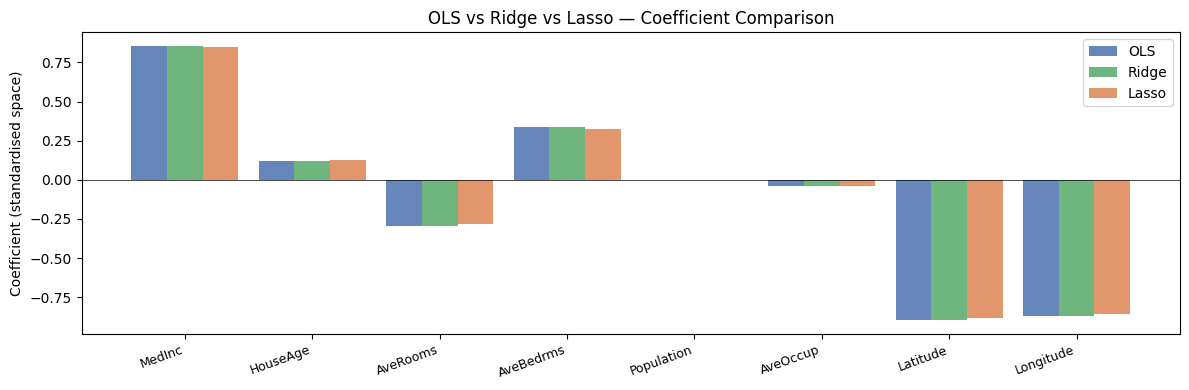

In [13]:
# ── Metrics table ─────────────────────────────────────────────────────────────
results = [
    {'Model': 'OLS',   **metrics_ols},
    {'Model': 'Ridge', **metrics_ridge},
    {'Model': 'Lasso', **metrics_lasso},
]
res_df = pd.DataFrame(results).set_index('Model')
print(res_df.round(4).to_string())

# ── Coefficient comparison bar chart ──────────────────────────────────────────
x  = np.arange(len(features))
w  = 0.28

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w, beta_ols,   w, label='OLS',   color='#4C72B0', alpha=0.85)
ax.bar(x,     beta_ridge, w, label='Ridge', color='#55A868', alpha=0.85)
ax.bar(x + w, beta_lasso, w, label='Lasso', color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Coefficient (standardised space)')
ax.set_title('OLS vs Ridge vs Lasso — Coefficient Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## Save Models to `../Models/`

In [15]:
np.savez_compressed('../Models/ridge_numpy.npz',
    beta         = beta_ridge,
    alpha        = np.array(best_alpha_ridge),
    x_mean       = X_mean, x_std = X_std, y_mean = np.array(y_mean),
    feature_names= np.array(features)
)
np.savez_compressed('../Models/lasso_numpy.npz',
    beta         = beta_lasso,
    alpha        = np.array(best_alpha_lasso),
    x_mean       = X_mean, x_std = X_std, y_mean = np.array(y_mean),
    feature_names= np.array(features)
)
for p in ['../Models/ridge_numpy.npz', '../Models/lasso_numpy.npz']:
    print(f"Saved → {p}  ({os.path.getsize(p)/1024:.1f} KB)")

Saved → ../Models/ridge_numpy.npz  (1.4 KB)
Saved → ../Models/lasso_numpy.npz  (1.4 KB)
